# D2C Customer Churn Intelligence
## Part 1 - Data Audit, EDA & Business Understanding

### Author
Viswa Musunuri

### Objective
Understand customer behavior, assess data quality, identify churn-risk patterns, and provide business recommendations.

# 1. Environment Setup & Imports

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


# 2. Load Datasets

In [53]:
DATA_PATH = Path("../data")

customers = pd.read_csv(DATA_PATH / "customers.csv")
orders = pd.read_csv(DATA_PATH / "orders.csv")
support = pd.read_csv(DATA_PATH / "support_tickets.csv")
web = pd.read_csv(DATA_PATH / "web_events_snapshot.csv")
labels = pd.read_csv(DATA_PATH / "churn_labels.csv")
interventions = pd.read_csv(DATA_PATH / "intervention_history.csv")
rfm_snapshot = pd.read_csv(DATA_PATH / "rfm_modeling_snapshot.csv")

print("All datasets loaded")

All datasets loaded


In [8]:
datasets = {
    "customers": customers,
    "orders": orders,
    "support": support,
    "web": web,
    "labels": labels,
    "interventions": interventions,
    "rfm_snapshot": rfm_snapshot
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-"*40)
    print("Shape:", df.shape)


CUSTOMERS
----------------------------------------
Shape: (2400, 9)

ORDERS
----------------------------------------
Shape: (10009, 10)

SUPPORT
----------------------------------------
Shape: (1921, 8)

WEB
----------------------------------------
Shape: (2400, 10)

LABELS
----------------------------------------
Shape: (2400, 4)

INTERVENTIONS
----------------------------------------
Shape: (2400, 5)

RFM_SNAPSHOT
----------------------------------------
Shape: (2400, 29)


# 3. Initial Data Audit

In [9]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


CUSTOMERS


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes



ORDERS


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0



SUPPORT


...

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train



INTERVENTIONS


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium



RFM_SNAPSHOT


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


In [10]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.info())


CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None

ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2  

In [11]:
missing_summary = []

for name, df in datasets.items():

    missing = df.isnull().sum()
    missing_pct = round((missing / len(df)) * 100, 2)

    temp = pd.DataFrame({
        "dataset": name,
        "column": missing.index,
        "missing_count": missing.values,
        "missing_pct": missing_pct.values
    })

    missing_summary.append(temp)

missing_summary = pd.concat(missing_summary)

missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_pct", ascending=False)

,dataset,column,missing_count,missing_pct
5,customers,loyalty_tier,1386,57.75
5,rfm_snapshot,loyalty_tier,1386,57.75
7,customers,skin_type,401,16.71
9,orders,rating,80,0.80


# 4. Data Quality Assessment

# Duplicate-like orders

In [12]:
dup_orders = orders[
    orders["order_id"].str.contains("_DUP", na=False)
]

print("Duplicate-like Orders:", len(dup_orders))
dup_orders.head()

Duplicate-like Orders: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


# Post-snapshot records

In [18]:
SNAPSHOT_DATE = pd.Timestamp("2025-09-30")

In [19]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

post_snapshot_orders = orders[
    orders["order_date"] > SNAPSHOT_DATE
]

print("Post Snapshot Orders")
print(post_snapshot_orders.shape)

Post Snapshot Orders
(1872, 10)


# Outlier investigation

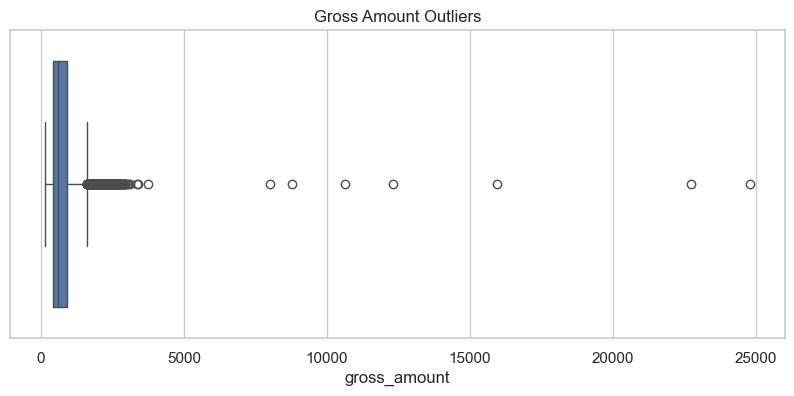

In [15]:
plt.figure(figsize=(10,4))
sns.boxplot(x=orders["gross_amount"])
plt.title("Gross Amount Outliers")
plt.show()

# Join consistency

In [16]:
for name, df in datasets.items():

    if "customer_id" in df.columns:

        missing_ids = (
            set(df["customer_id"])
            - set(customers["customer_id"])
        )

        print(
            name,
            "unmatched customer ids:",
            len(missing_ids)
        )

customers unmatched customer ids: 0
orders unmatched customer ids: 0
support unmatched customer ids: 0
web unmatched customer ids: 0
labels unmatched customer ids: 0
interventions unmatched customer ids: 0
rfm_snapshot unmatched customer ids: 0


In [20]:
SNAPSHOT_DATE = pd.Timestamp("2025-09-30")

orders_pre_snapshot = orders[
    orders["order_date"] <= SNAPSHOT_DATE
].copy()

orders_post_snapshot = orders[
    orders["order_date"] > SNAPSHOT_DATE
].copy()

print("Pre Snapshot Orders:", orders_pre_snapshot.shape)
print("Post Snapshot Orders:", orders_post_snapshot.shape)

Pre Snapshot Orders: (8137, 10)
Post Snapshot Orders: (1872, 10)


# 5. Exploratory Data Analysis

# Chart 1 — Churn Distribution

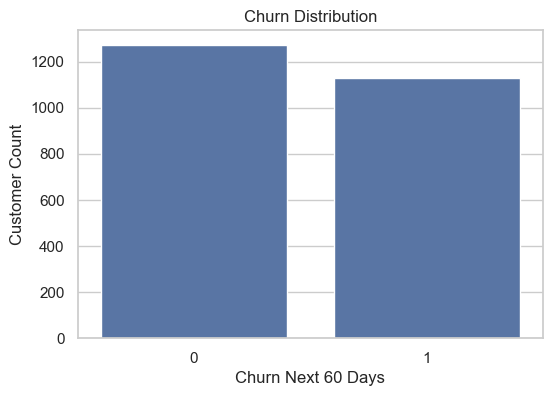

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=labels,
    x="churn_next_60d"
)

plt.title("Churn Distribution")
plt.xlabel("Churn Next 60 Days")
plt.ylabel("Customer Count")

plt.show()

labels["churn_next_60d"].value_counts(normalize=True)*100

# Chart 2 — Customer Acquisition Channel

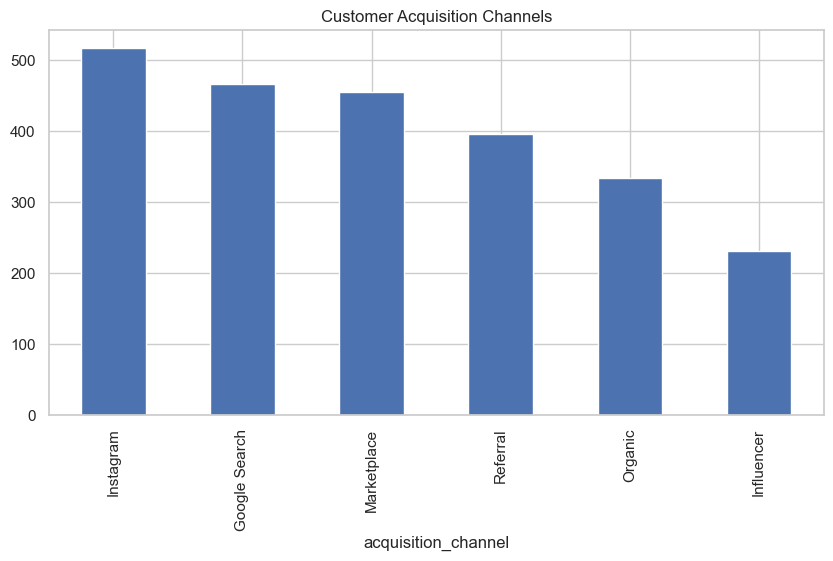

In [22]:
plt.figure(figsize=(10,5))

customers["acquisition_channel"]\
.value_counts()\
.plot(kind="bar")

plt.title("Customer Acquisition Channels")

plt.show()

# Chart 3 — Preferred Category Distribution

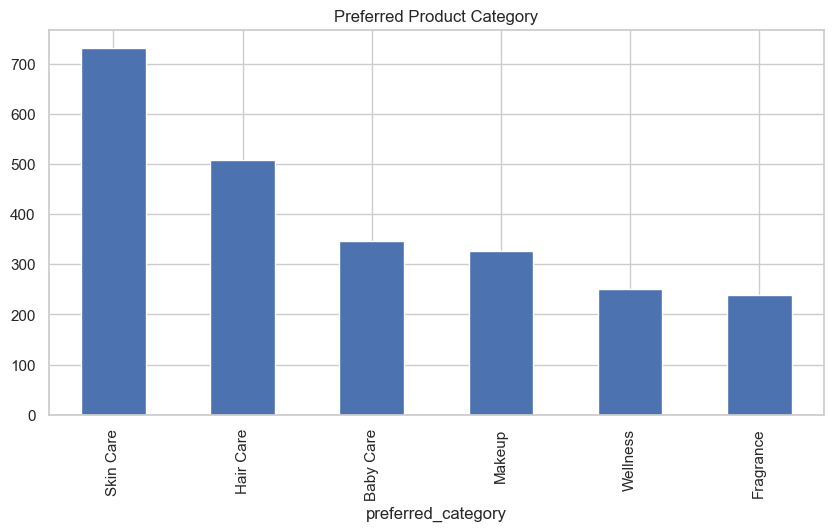

In [23]:
plt.figure(figsize=(10,5))

customers["preferred_category"]\
.value_counts()\
.plot(kind="bar")

plt.title("Preferred Product Category")

plt.show()

# Chart 4 — Order Category Distribution

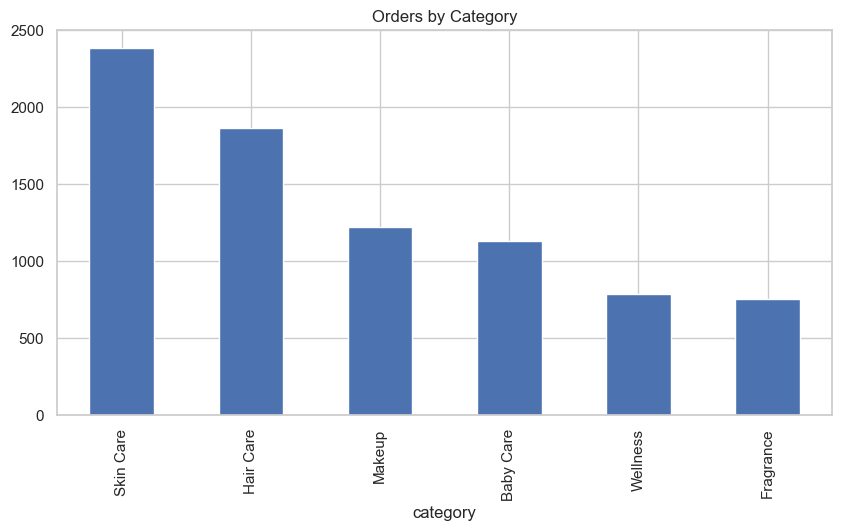

In [25]:
plt.figure(figsize=(10,5))

orders_pre_snapshot["category"]\
.value_counts()\
.plot(kind="bar")

plt.title("Orders by Category")

plt.show()

# Chart 5 — Support Ticket Issues

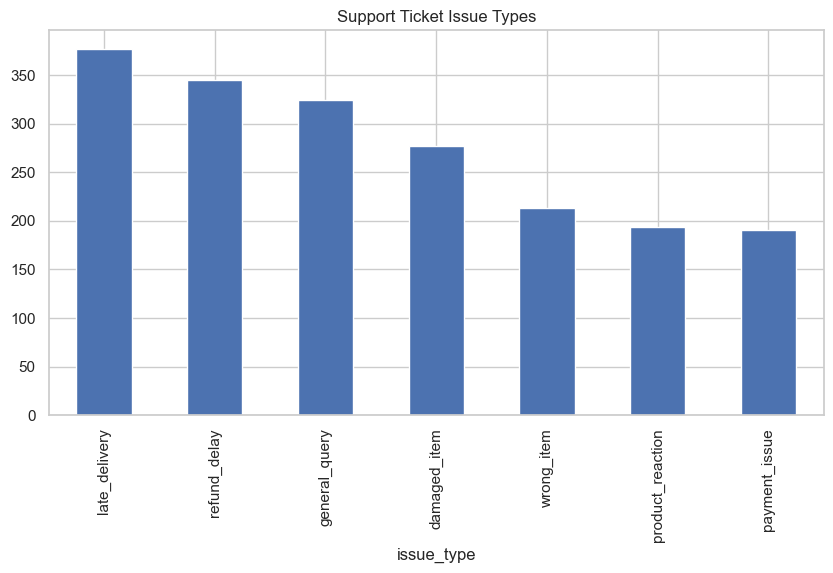

In [26]:
plt.figure(figsize=(10,5))

support["issue_type"]\
.value_counts()\
.plot(kind="bar")

plt.title("Support Ticket Issue Types")

plt.show()

# Chart 6 — Churn by Loyalty Tier

In [27]:
customer_churn = customers.merge(
    labels,
    on="customer_id",
    how="left"
)

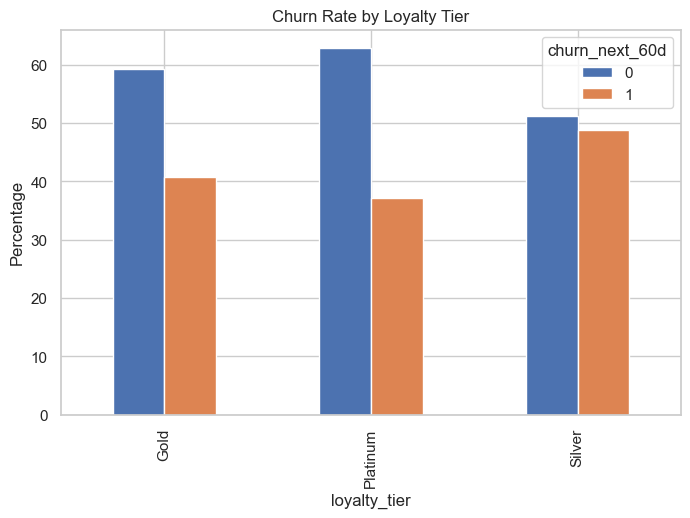

In [28]:
churn_loyalty = pd.crosstab(
    customer_churn["loyalty_tier"],
    customer_churn["churn_next_60d"],
    normalize="index"
)*100

churn_loyalty.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Loyalty Tier")
plt.ylabel("Percentage")

plt.show()

# 6. Churn Risk Analysis & Hypothesis Generation

In [29]:
analysis_df = rfm_snapshot.copy()

analysis_df["churn_next_60d"] = (
    analysis_df["churn_next_60d"]
    .astype(int)
)

analysis_df.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


# Hypothesis 1
# Recency vs Churn

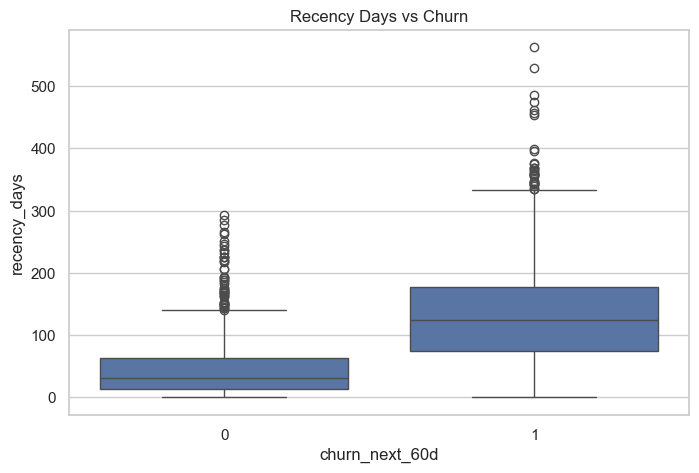

churn_next_60d
0     45.074627
1    135.157054
Name: recency_days, dtype: float64

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="recency_days"
)

plt.title("Recency Days vs Churn")

plt.show()

analysis_df.groupby(
    "churn_next_60d"
)["recency_days"].mean()

# Hypothesis 2
# Frequency vs Churn

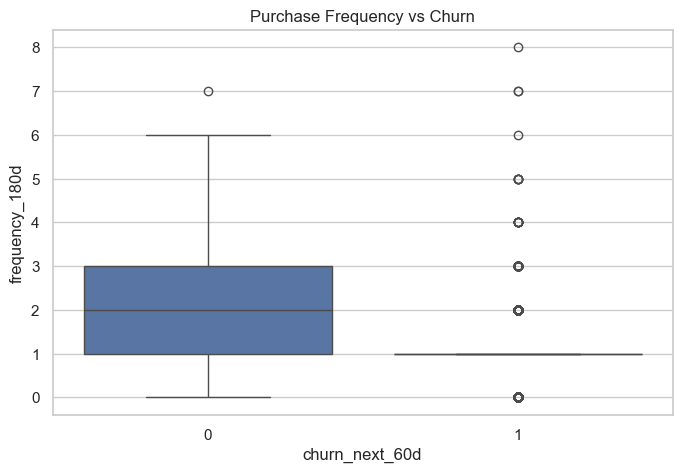

churn_next_60d
0    2.033778
1    1.098492
Name: frequency_180d, dtype: float64

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="frequency_180d"
)

plt.title("Purchase Frequency vs Churn")

plt.show()

analysis_df.groupby(
    "churn_next_60d"
)["frequency_180d"].mean()

# Hypothesis 3
# Monetary Value vs Churn

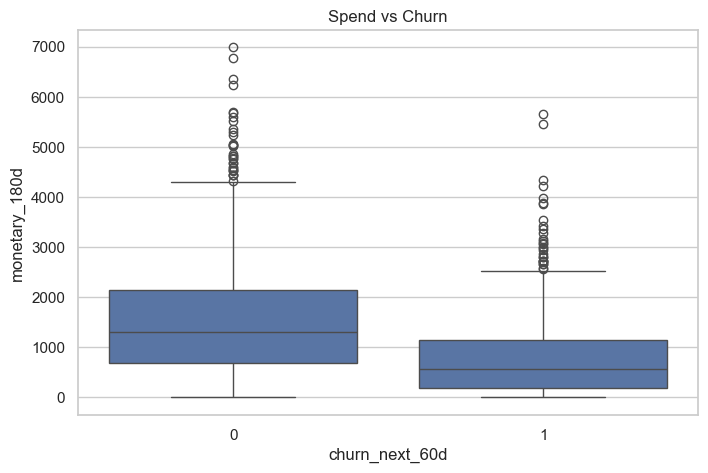

churn_next_60d
0    1554.730778
1     756.219512
Name: monetary_180d, dtype: float64

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="monetary_180d"
)

plt.title("Spend vs Churn")

plt.show()

analysis_df.groupby(
    "churn_next_60d"
)["monetary_180d"].mean()

# Hypothesis 4
# Ticket Count vs Churn

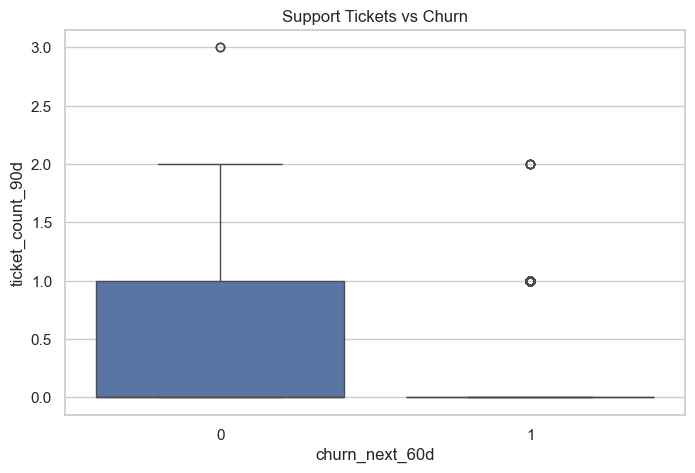

churn_next_60d
0    0.296936
1    0.152618
Name: ticket_count_90d, dtype: float64

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="ticket_count_90d"
)

plt.title("Support Tickets vs Churn")

plt.show()

analysis_df.groupby(
    "churn_next_60d"
)["ticket_count_90d"].mean()

# Hypothesis 5
# Sessions vs Churn

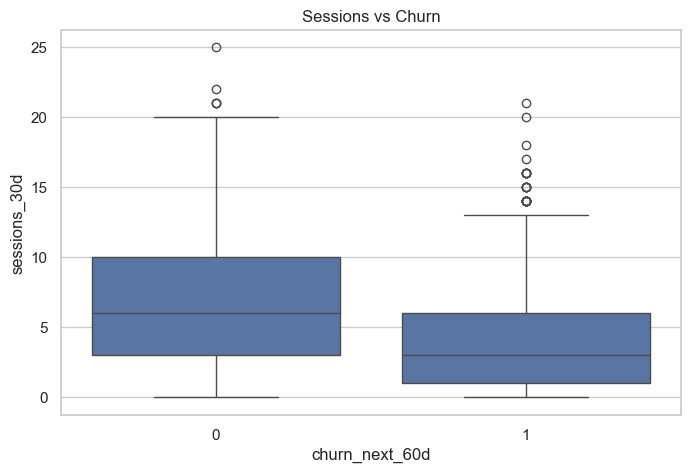

churn_next_60d
0    6.732129
1    4.023070
Name: sessions_30d, dtype: float64

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="sessions_30d"
)

plt.title("Sessions vs Churn")

plt.show()

analysis_df.groupby(
    "churn_next_60d"
)["sessions_30d"].mean()

# 7. Additional Churn Driver Analysis

# Loyalty Tier vs Churn Rate

churn_next_60d,0,1
loyalty_tier,,
Gold,59.247649,40.752351
Platinum,62.857143,37.142857
Silver,51.186441,48.813559


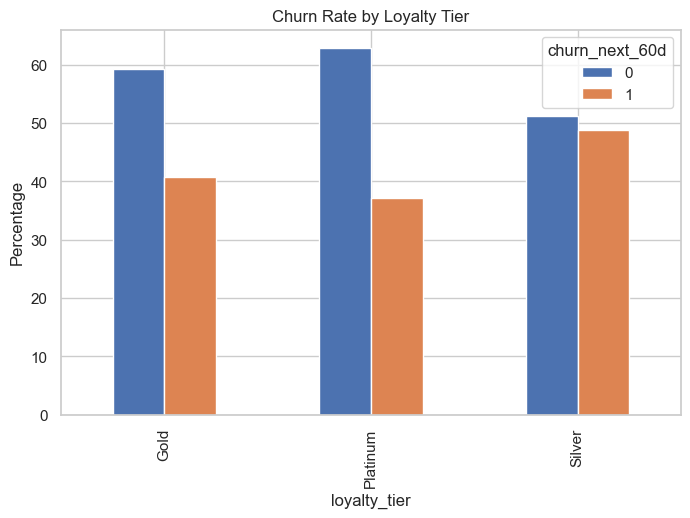

In [35]:
loyalty_analysis = pd.crosstab(
    analysis_df["loyalty_tier"],
    analysis_df["churn_next_60d"],
    normalize="index"
) * 100

display(loyalty_analysis)

loyalty_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Loyalty Tier")
plt.ylabel("Percentage")
plt.show()

# Marketing Consent vs Churn

churn_next_60d,0,1
marketing_consent,,
No,52.031250,47.968750
Yes,53.409091,46.590909


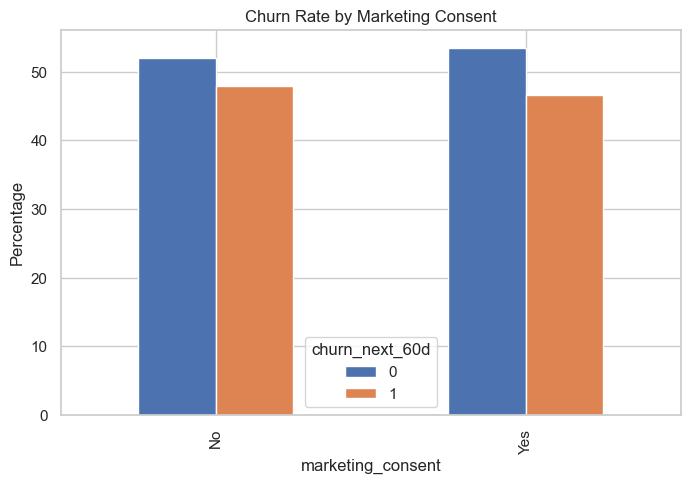

In [36]:
marketing_analysis = pd.crosstab(
    analysis_df["marketing_consent"],
    analysis_df["churn_next_60d"],
    normalize="index"
) * 100

display(marketing_analysis)

marketing_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Marketing Consent")
plt.ylabel("Percentage")
plt.show()

# Negative Ticket Rate vs Churn

In [38]:
analysis_df.groupby(
    "churn_next_60d"
)["negative_ticket_rate_90d"].mean()

churn_next_60d
0    0.162346
1    0.112245
Name: negative_ticket_rate_90d, dtype: float64

# 8. Executive Findings Summary

In [39]:
summary_table = pd.DataFrame({
    "Metric": [
        "Avg Recency",
        "Avg Frequency",
        "Avg Monetary",
        "Avg Sessions",
        "Avg Ticket Count"
    ],
    "Retained_Customers": [
        analysis_df.groupby("churn_next_60d")["recency_days"].mean()[0],
        analysis_df.groupby("churn_next_60d")["frequency_180d"].mean()[0],
        analysis_df.groupby("churn_next_60d")["monetary_180d"].mean()[0],
        analysis_df.groupby("churn_next_60d")["sessions_30d"].mean()[0],
        analysis_df.groupby("churn_next_60d")["ticket_count_90d"].mean()[0]
    ],
    "Churned_Customers": [
        analysis_df.groupby("churn_next_60d")["recency_days"].mean()[1],
        analysis_df.groupby("churn_next_60d")["frequency_180d"].mean()[1],
        analysis_df.groupby("churn_next_60d")["monetary_180d"].mean()[1],
        analysis_df.groupby("churn_next_60d")["sessions_30d"].mean()[1],
        analysis_df.groupby("churn_next_60d")["ticket_count_90d"].mean()[1]
    ]
})

summary_table

,Metric,Retained_Customers,Churned_Customers
0,Avg Recency,45.074627,135.157054
1,Avg Frequency,2.033778,1.098492
2,Avg Monetary,1554.730778,756.219512
3,Avg Sessions,6.732129,4.023070
4,Avg Ticket Count,0.296936,0.152618


# 9. Export Key Visualizations

In [41]:
from pathlib import Path

CHART_PATH = Path("../charts")
CHART_PATH.mkdir(parents=True, exist_ok=True)

print(f"Charts will be saved to: {CHART_PATH.resolve()}")

Charts will be saved to: C:\Users\viswa\OneDrive\Documents\AIML - Projects\ai-Customer-Churn-Intelligence-Retention\d2c-churn-part1-eda\charts


In [42]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        CHART_PATH / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# Chart 1 — Churn Distribution

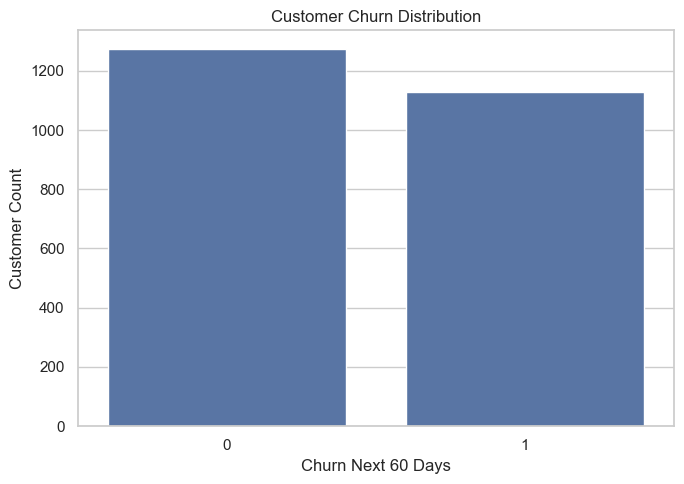

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=labels,
    x="churn_next_60d"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Next 60 Days")
plt.ylabel("Customer Count")

save_plot("churn_distribution.png")

# Chart 2 — Loyalty Tier vs Churn

<Figure size 800x500 with 0 Axes>

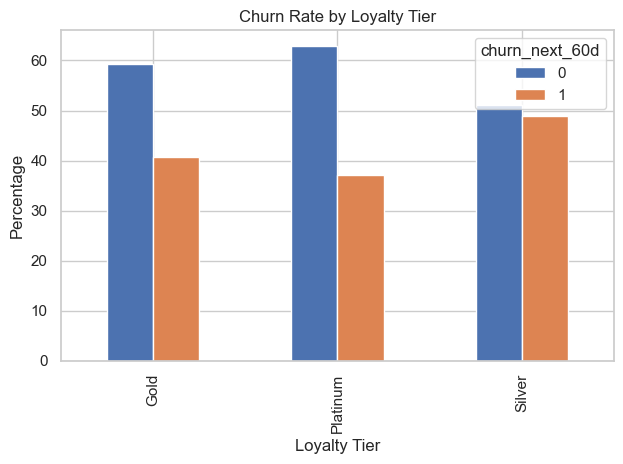

In [44]:
loyalty_analysis = pd.crosstab(
    analysis_df["loyalty_tier"],
    analysis_df["churn_next_60d"],
    normalize="index"
) * 100

plt.figure(figsize=(8,5))

loyalty_analysis.plot(
    kind="bar"
)

plt.title("Churn Rate by Loyalty Tier")
plt.xlabel("Loyalty Tier")
plt.ylabel("Percentage")

save_plot("loyalty_vs_churn.png")

# Chart 3 — Recency vs Churn

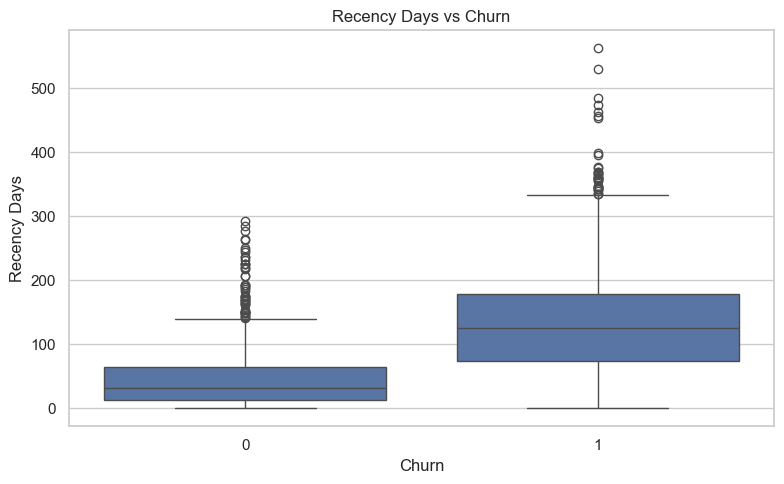

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="recency_days"
)

plt.title("Recency Days vs Churn")
plt.xlabel("Churn")
plt.ylabel("Recency Days")

save_plot("recency_vs_churn.png")

# Chart 4 — Frequency vs Churn

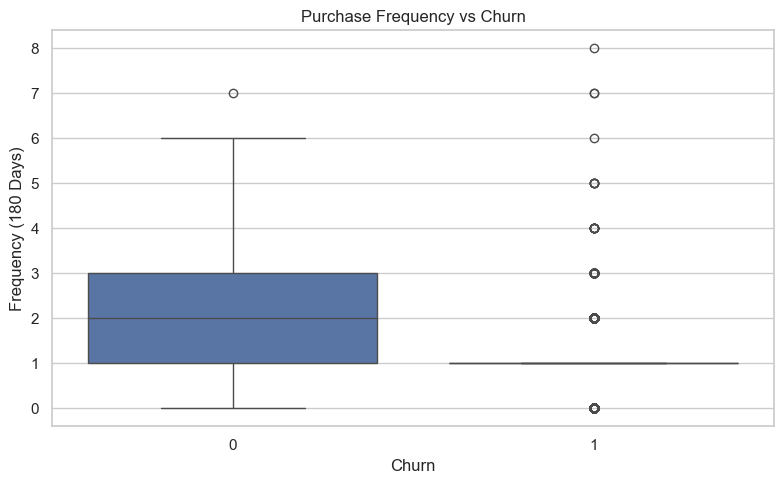

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="frequency_180d"
)

plt.title("Purchase Frequency vs Churn")
plt.xlabel("Churn")
plt.ylabel("Frequency (180 Days)")

save_plot("frequency_vs_churn.png")

# Chart 5 — Sessions vs Churn

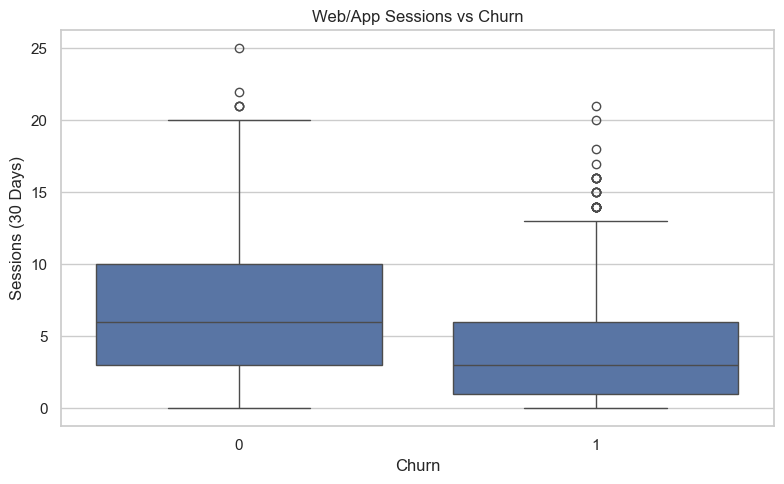

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="sessions_30d"
)

plt.title("Web/App Sessions vs Churn")
plt.xlabel("Churn")
plt.ylabel("Sessions (30 Days)")

save_plot("sessions_vs_churn.png")

# Chart 6 — Monetary Value vs Churn

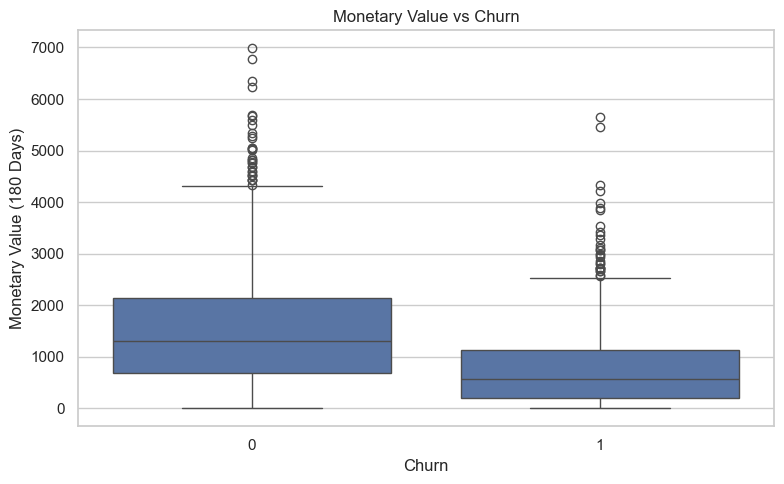

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=analysis_df,
    x="churn_next_60d",
    y="monetary_180d"
)

plt.title("Monetary Value vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monetary Value (180 Days)")

save_plot("monetary_vs_churn.png")

# 10. Conclusion

Key findings:

- Churned customers exhibit significantly higher recency.
- Churned customers purchase less frequently.
- Churned customers spend substantially less.
- Lower web/app engagement is associated with churn.
- Support interactions appear to indicate engagement rather than dissatisfaction alone.

These findings suggest retention efforts should focus on customers showing declining purchase activity and declining digital engagement before they become inactive.